In [7]:
# =========================
# KOMÓRKA 0: BALANSOWANIE DANYCH TYLKO DLA KOBIET, KLASY 0 I 1
# =========================

import pandas as pd
import numpy as np
import os
from pathlib import Path
from IPython.display import display

RANDOM_STATE = 42

SOURCE_TRAIN_CSV = "validated_train.csv"
SOURCE_TEST_CSV = "validated_test.csv"

TRAIN_SPEC_DIR = "validated_train/spectrograms"
TEST_SPEC_DIR = "validated_test/spectrograms"

BALANCED_TRAIN_CSV = "balanced_female_validated_train.csv"
BALANCED_TEST_CSV = "balanced_female_validated_test.csv"

TARGET_GENDER = "female"

# Bierzemy pod uwagę tylko klasy 0 i 1 z uwagi na bardzo mala reprezentacje klasy 2 w zbiorze treningowym
EXPECTED_CLASSES = [0, 1]


def normalize_gender(value):
    value = str(value).lower().strip()

    gender_map = {
        "female_feminine": "female",
        "female": "female",
        "woman": "female",
        "women": "female",

        "male_masculine": "male",
        "male": "male",
        "man": "male",
        "men": "male",

        "nan": "unknown",
        "": "unknown"
    }

    return gender_map.get(value, value)


def add_spectrogram_path(df, spec_dir):
    df = df.copy()

    df["npy_name"] = df["path"].apply(
        lambda x: Path(str(x)).with_suffix(".npy").name
    )

    df["spec_path"] = df["npy_name"].apply(
        lambda name: os.path.join(spec_dir, name)
    )

    df["has_spectrogram"] = df["spec_path"].apply(os.path.exists)

    return df


def balance_dataset_by_class_and_gender(csv_path, spec_dir, output_csv, target_gender):
    print("=" * 80)
    print(f"Przetwarzanie: {csv_path}")
    print(f"Wybrana płeć: {target_gender}")

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    required_columns = ["path", "age", "gender", "age_cat"]
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(f"W pliku {csv_path} brakuje kolumn: {missing_columns}")

    df = df.copy()

    print(f"Liczba rekordów w CSV przed filtrowaniem: {len(df)}")

    df["gender_clean"] = df["gender"].apply(normalize_gender)
    df["age_cat"] = pd.to_numeric(df["age_cat"], errors="coerce")

    df = df[df["age_cat"].notna()].copy()
    df["age_cat"] = df["age_cat"].astype(int)

    df = df[df["gender_clean"] == target_gender].copy()

    print(f"Liczba rekordów po wybraniu płci {target_gender}: {len(df)}")

    if len(df) == 0:
        raise ValueError(f"Brak rekordów dla płci: {target_gender}")

    df = add_spectrogram_path(df, spec_dir)

    print(f"Liczba rekordów z istniejącym spektrogramem .npy: {df['has_spectrogram'].sum()}")
    print(f"Liczba rekordów bez spektrogramu .npy: {(~df['has_spectrogram']).sum()}")

    df_valid = df[df["has_spectrogram"]].copy()

    if len(df_valid) == 0:
        raise ValueError(
            f"Nie znaleziono żadnych pasujących spektrogramów .npy dla {csv_path}. "
            f"Sprawdź spec_dir={spec_dir}"
        )

    existing_classes = sorted(df_valid["age_cat"].unique())

    print("\nWykryte klasy:")
    print(existing_classes)

    if EXPECTED_CLASSES is not None:
        missing_expected = sorted(set(EXPECTED_CLASSES) - set(existing_classes))

        if missing_expected:
            raise ValueError(
                f"Po filtrowaniu dla płci {target_gender} brakuje klas: {missing_expected}. "
                f"Nie da się poprawnie zbalansować pełnego zbioru klas {EXPECTED_CLASSES}."
            )

        df_valid = df_valid[df_valid["age_cat"].isin(EXPECTED_CLASSES)].copy()

    print("\nLiczebność klas przed balansowaniem:")
    class_counts_before = (
        df_valid
        .groupby(["age_cat", "age"])
        .size()
        .reset_index(name="liczba")
        .sort_values("age_cat")
    )
    display(class_counts_before)

    class_counts = df_valid["age_cat"].value_counts().sort_index()

    print("\nLiczebność age_cat:")
    display(class_counts)

    min_class_count = class_counts.min()

    print(f"Najmniej reprezentowana klasa ma: {min_class_count} próbek")
    print(f"Z każdej klasy zostanie wybrane po: {min_class_count} próbek")

    balanced_parts = []

    for class_id in sorted(df_valid["age_cat"].unique()):
        class_subset = df_valid[df_valid["age_cat"] == class_id].copy()

        sampled_subset = class_subset.sample(
            n=min_class_count,
            random_state=RANDOM_STATE
        )

        balanced_parts.append(sampled_subset)

    balanced_df = pd.concat(balanced_parts, ignore_index=True)

    balanced_df = balanced_df.sample(
        frac=1,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    print("\nLiczebność klas po balansowaniu:")
    class_counts_after = (
        balanced_df
        .groupby(["age_cat", "age"])
        .size()
        .reset_index(name="liczba")
        .sort_values("age_cat")
    )
    display(class_counts_after)

    balanced_df_to_save = balanced_df[["path", "age", "gender", "age_cat"]].copy()
    balanced_df_to_save.to_csv(output_csv, index=False)

    print(f"\nZapisano plik: {output_csv}")
    print(f"Liczba rekordów po balansowaniu: {len(balanced_df_to_save)}")

    return balanced_df_to_save


balanced_train = balance_dataset_by_class_and_gender(
    csv_path=SOURCE_TRAIN_CSV,
    spec_dir=TRAIN_SPEC_DIR,
    output_csv=BALANCED_TRAIN_CSV,
    target_gender=TARGET_GENDER
)

balanced_test = balance_dataset_by_class_and_gender(
    csv_path=SOURCE_TEST_CSV,
    spec_dir=TEST_SPEC_DIR,
    output_csv=BALANCED_TEST_CSV,
    target_gender=TARGET_GENDER
)

TRAIN_CSV = BALANCED_TRAIN_CSV
TEST_CSV = BALANCED_TEST_CSV

print("=" * 80)
print("Gotowe — wersja tylko dla kobiet, klasy 0 i 1.")
print(f"TRAIN_CSV = {TRAIN_CSV}")
print(f"TEST_CSV = {TEST_CSV}")

Przetwarzanie: validated_train.csv
Wybrana płeć: female
Liczba rekordów w CSV przed filtrowaniem: 70699
Liczba rekordów po wybraniu płci female: 13536
Liczba rekordów z istniejącym spektrogramem .npy: 13536
Liczba rekordów bez spektrogramu .npy: 0

Wykryte klasy:
[np.int64(0), np.int64(1), np.int64(2)]

Liczebność klas przed balansowaniem:


,age_cat,age,liczba
0,0,teens,107
1,0,twenties,8138
2,1,fourties,458
3,1,thirties,4792



Liczebność age_cat:


age_cat
0    8245
1    5250
Name: count, dtype: int64

Najmniej reprezentowana klasa ma: 5250 próbek
Z każdej klasy zostanie wybrane po: 5250 próbek

Liczebność klas po balansowaniu:


...


Liczebność age_cat:


age_cat
0    3544
1    2333
Name: count, dtype: int64

Najmniej reprezentowana klasa ma: 2333 próbek
Z każdej klasy zostanie wybrane po: 2333 próbek

Liczebność klas po balansowaniu:


,age_cat,age,liczba
0,0,teens,32
1,0,twenties,2301
2,1,fourties,187
3,1,thirties,2146



Zapisano plik: balanced_female_validated_test.csv
Liczba rekordów po balansowaniu: 4666
Gotowe — wersja tylko dla kobiet, klasy 0 i 1.
TRAIN_CSV = balanced_female_validated_train.csv
TEST_CSV = balanced_female_validated_test.csv


In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm

# =========================
# KONFIGURACJA
# =========================
TRAIN_CSV = "balanced_female_validated_train.csv"
TRAIN_SPEC_DIR = "validated_train/spectrograms"
MODEL_PATH = "age_classifier_female_best_balanced.pth"
HISTORY_CSV = "training_history_female.csv"

EPOCHS = 40
BATCH_SIZE = 32
LR = 0.001
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.10
SEED = 42
ALLOWED_CLASSES = [0, 1]


def spectrogram_path_from_mp3_name(spec_dir, mp3_path):
    """
    Z CSV bierzemy np. common_voice_pl_20685868.mp3,
    a na dysku szukamy train/common_voice_pl_20685868.npy.
    """
    npy_name = Path(str(mp3_path)).with_suffix(".npy").name
    return os.path.join(spec_dir, npy_name)


def make_class_to_age_map(*csv_paths):
    """
    Tworzy mapowanie np. 0 -> twenties, 1 -> sixties itd.
    Używane tylko do czytelnego opisu wyników, model dalej uczy się klas liczbowych.
    """
    frames = []
    for csv_path in csv_paths:
        if os.path.exists(csv_path):
            frames.append(pd.read_csv(csv_path))

    if not frames:
        return {}

    df = pd.concat(frames, ignore_index=True)
    df = df[df["age_cat"].notna() & df["age"].notna()].copy()
    df["age_cat"] = df["age_cat"].astype(int)
    df = df[df["age_cat"].isin(ALLOWED_CLASSES)].copy()

    mapping = {}
    for class_id, group in df.groupby("age_cat"):
        mapping[int(class_id)] = group["age"].mode().iloc[0]

    return mapping


class AudioAgeDataset(Dataset):
    def __init__(self, csv_file, spec_dir, return_info=False):
        self.csv_file = csv_file
        self.spec_dir = spec_dir
        self.return_info = return_info

        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["age_cat"].notna()].copy()
        self.df["age_cat"] = self.df["age_cat"].astype(int)

        before_class_filter = len(self.df)
        self.df = self.df[self.df["age_cat"].isin(ALLOWED_CLASSES)].copy()
        skipped_classes = before_class_filter - len(self.df)
        if skipped_classes > 0:
            print(f"Pominięto {skipped_classes} próbek spoza klas {ALLOWED_CLASSES}")

        self.df["spec_path"] = self.df["path"].apply(
            lambda p: spectrogram_path_from_mp3_name(self.spec_dir, p)
        )

        before = len(self.df)
        self.df = self.df[self.df["spec_path"].apply(os.path.exists)].reset_index(drop=True)
        missing = before - len(self.df)

        print(f"Wczytano {len(self.df)} poprawnych próbek z {csv_file}")
        if missing > 0:
            print(f"Pominięto {missing} próbek, bo nie znaleziono odpowiadających plików .npy")

        if len(self.df) == 0:
            raise RuntimeError(
                f"Brak próbek po sprawdzeniu plików .npy. Sprawdź csv_file={csv_file} oraz spec_dir={spec_dir}"
            )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        mel_db = np.load(row["spec_path"])
        mel_tensor = torch.from_numpy(mel_db).unsqueeze(0).float()  # [1, n_mels, czas]
        label = int(row["age_cat"])

        if self.return_info:
            return mel_tensor, label, str(row["path"]), str(row.get("age", ""))

        return mel_tensor, label


def pad_collate(batch):
    """
    Pozwala ładować batch nawet wtedy, gdy spektrogramy mają różną długość w osi czasu.
    Jeśli wszystkie spektrogramy mają identyczny rozmiar, ta funkcja też działa normalnie.
    """
    has_info = len(batch[0]) == 4

    if has_info:
        tensors, labels, paths, ages = zip(*batch)
    else:
        tensors, labels = zip(*batch)

    max_h = max(t.shape[1] for t in tensors)
    max_w = max(t.shape[2] for t in tensors)

    padded = []
    for t in tensors:
        pad_h = max_h - t.shape[1]
        pad_w = max_w - t.shape[2]
        padded.append(F.pad(t, (0, pad_w, 0, pad_h)))

    inputs = torch.stack(padded)
    labels = torch.tensor(labels, dtype=torch.long)

    if has_info:
        return inputs, labels, list(paths), list(ages)

    return inputs, labels


class AgeClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super(AgeClassifier, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        # Bez +1, bo nie dokładamy już wektora płci.
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc_layers(x)


def train_model():
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Używane urządzenie: {device}")

    full_dataset = AudioAgeDataset(TRAIN_CSV, TRAIN_SPEC_DIR)

    unique_classes = sorted(full_dataset.df["age_cat"].unique())
    print(f"Używane klasy: {unique_classes}")
    if unique_classes != ALLOWED_CLASSES:
        raise ValueError(f"Po filtrowaniu oczekiwano klas {ALLOWED_CLASSES}, ale znaleziono {unique_classes}")

    num_classes = int(max(ALLOWED_CLASSES)) + 1
    class_to_age = make_class_to_age_map(TRAIN_CSV)
    print(f"Liczba klas: {num_classes}")
    print(f"Mapowanie klas: {class_to_age}")

    val_size = int(VAL_SPLIT * len(full_dataset))
    train_size = len(full_dataset) - val_size

    generator = torch.Generator().manual_seed(SEED)
    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=generator
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pad_collate
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pad_collate
    )

    model = AgeClassifier(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    best_val_loss = float("inf")
    history = []

    for epoch in range(EPOCHS):
        model.train()
        running_train_loss = 0.0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} [TRAIN]")
        for inputs, labels in train_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            train_bar.set_postfix({"train_loss": f"{loss.item():.4f}"})

        avg_train_loss = running_train_loss / len(train_loader)

        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100.0 * val_correct / val_total

        row = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": val_acc
        }
        history.append(row)
        pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

        print(
            f"Epoch {epoch + 1}: "
            f"Train Loss={avg_train_loss:.4f} | "
            f"Val Loss={avg_val_loss:.4f} | "
            f"Val Acc={val_acc:.2f}%"
        )

        scheduler.step()

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "num_classes": num_classes,
                    "class_to_age": class_to_age,
                    "history": history,
                },
                MODEL_PATH
            )
            print(f"--> Zapisano najlepszy model: {MODEL_PATH}, Val Loss={best_val_loss:.4f}")

    return model, pd.DataFrame(history), class_to_age


# model, history_df, class_to_age = train_model()
# print("Trening zakończony.")
# print(history_df.tail())


In [9]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# =========================
# KONFIGURACJA TESTU
# =========================
TEST_CSV = "balanced_female_validated_test.csv"
TEST_SPEC_DIR = "validated_test/spectrograms"
MODEL_PATH = "age_classifier_female_best_balanced.pth"
RESULTS_CSV = "test_predictions_female.csv"


def load_trained_model(model_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(model_path, map_location=device)

    # Obsługa zarówno nowego zapisu checkpoint, jak i starego samego state_dict.
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        num_classes = int(checkpoint.get("num_classes", 3))
        class_to_age = checkpoint.get("class_to_age", {})
        state_dict = checkpoint["model_state_dict"]
    else:
        test_df = pd.read_csv(TEST_CSV)
        test_df = test_df[test_df["age_cat"].isin(ALLOWED_CLASSES)].copy()
        num_classes = int(max(ALLOWED_CLASSES)) + 1
        class_to_age = make_class_to_age_map(TEST_CSV)
        state_dict = checkpoint

    class_to_age = {int(k): v for k, v in class_to_age.items()}

    model = AgeClassifier(num_classes=num_classes).to(device)
    model.load_state_dict(state_dict)
    model.eval()

    return model, device, class_to_age, num_classes


def evaluate_on_test_set():
    model, device, class_to_age, num_classes = load_trained_model(MODEL_PATH)

    test_dataset = AudioAgeDataset(TEST_CSV, TEST_SPEC_DIR, return_info=True)
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pad_collate
    )

    rows = []

    with torch.no_grad():
        for inputs, labels, paths, ages in tqdm(test_loader, desc="Testowanie"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            confidences = probs.max(dim=1).values

            probs_cpu = probs.cpu().numpy()
            labels_cpu = labels.cpu().numpy()
            preds_cpu = preds.cpu().numpy()
            confidences_cpu = confidences.cpu().numpy()

            for i in range(len(paths)):
                result_row = {
                    "path": paths[i],
                    "true_age": ages[i],
                    "true_class": int(labels_cpu[i]),
                    "predicted_class": int(preds_cpu[i]),
                    "predicted_age": class_to_age.get(int(preds_cpu[i]), str(int(preds_cpu[i]))),
                    "correct": int(labels_cpu[i] == preds_cpu[i]),
                    "confidence": float(confidences_cpu[i]),
                }

                for class_id in range(num_classes):
                    result_row[f"prob_class_{class_id}"] = float(probs_cpu[i, class_id])

                rows.append(result_row)

    results_df = pd.DataFrame(rows)
    results_df.to_csv(RESULTS_CSV, index=False)

    overall_acc = results_df["correct"].mean() * 100
    print(f"Zapisano wyniki do: {RESULTS_CSV}")
    print(f"Accuracy na zbiorze testowym: {overall_acc:.2f}%")
    print(f"Liczba przetestowanych próbek: {len(results_df)}")

    display(results_df.head())
    return results_df


results_df = evaluate_on_test_set()


Wczytano 4666 poprawnych próbek z balanced_female_validated_test.csv


Testowanie: 100%|██████████| 146/146 [00:23<00:00,  6.18it/s]

Zapisano wyniki do: test_predictions_female.csv
Accuracy na zbiorze testowym: 98.35%
Liczba przetestowanych próbek: 4666


,path,true_age,true_class,predicted_class,predicted_age,correct,confidence,prob_class_0,prob_class_1
0,common_voice_pl_21691670.mp3,thirties,1,1,thirties,1,1.000000,4.046737e-08,1.000000e+00
1,common_voice_pl_20818598.mp3,thirties,1,1,thirties,1,0.999999,6.982071e-07,9.999993e-01
2,common_voice_pl_20643648.mp3,thirties,1,1,thirties,1,0.999985,1.518108e-05,9.999849e-01
3,common_voice_pl_20637507.mp3,twenties,0,0,twenties,1,0.999010,9.990102e-01,9.897966e-04
4,common_voice_pl_20680706.mp3,twenties,0,0,twenties,1,1.000000,1.000000e+00,4.099580e-08


Accuracy dla poszczególnych kategorii:


,true_class,true_age,samples,accuracy_percent
0,0,teens,32,87.500000
1,0,twenties,2301,98.783138
2,1,fourties,187,96.256684
3,1,thirties,2146,98.229264


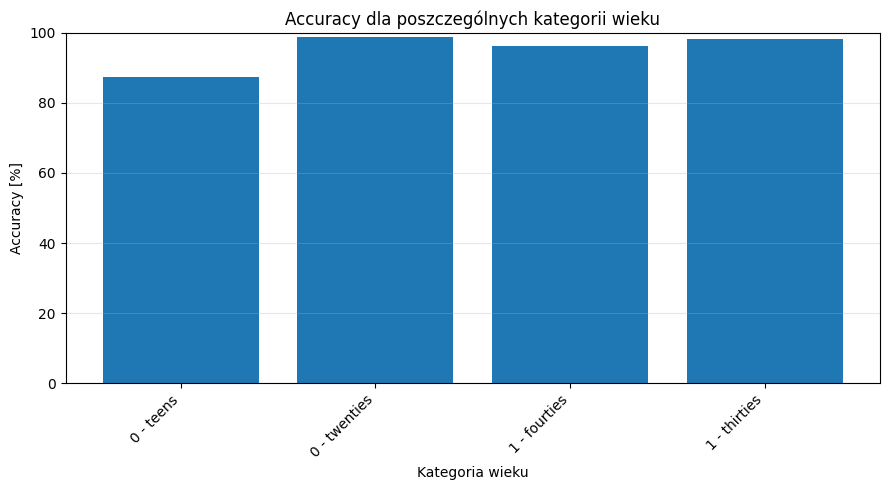

Confusion matrix — liczba próbek:


Klasa przewidziana,0,1
Klasa prawdziwa,,
0,2301,32
1,45,2288


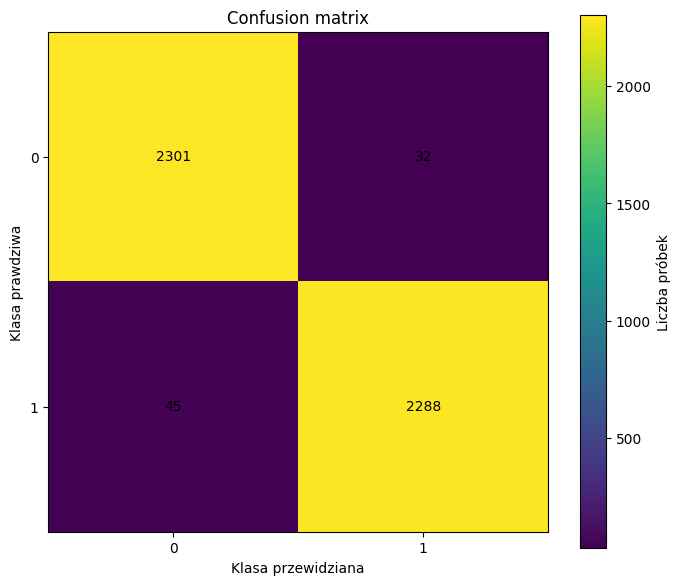

Confusion matrix — procentowo w ramach klasy prawdziwej:


Klasa przewidziana,0,1
Klasa prawdziwa,,
0,98.63,1.37
1,1.93,98.07


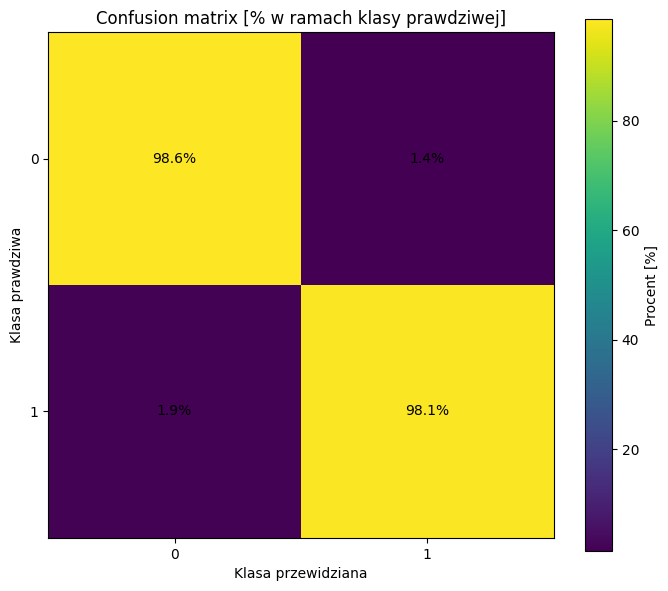

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_CSV = "test_predictions_female.csv"

results_df = pd.read_csv(RESULTS_CSV)

# =========================
# ACCURACY DLA KATEGORII
# =========================
per_class = (
    results_df
    .groupby(["true_class", "true_age"], dropna=False)["correct"]
    .agg(samples="count", accuracy="mean")
    .reset_index()
)
per_class["accuracy_percent"] = per_class["accuracy"] * 100
per_class["label"] = per_class.apply(
    lambda row: f"{int(row['true_class'])} - {row['true_age']}",
    axis=1
)

print("Accuracy dla poszczególnych kategorii:")
display(per_class[["true_class", "true_age", "samples", "accuracy_percent"]])

plt.figure(figsize=(9, 5))
plt.bar(per_class["label"], per_class["accuracy_percent"])
plt.ylim(0, 100)
plt.xlabel("Kategoria wieku")
plt.ylabel("Accuracy [%]")
plt.title("Accuracy dla poszczególnych kategorii wieku")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# CONFUSION MATRIX
# =========================
labels = sorted(set(results_df["true_class"]).union(set(results_df["predicted_class"])))

cm = pd.crosstab(
    results_df["true_class"],
    results_df["predicted_class"],
    rownames=["Klasa prawdziwa"],
    colnames=["Klasa przewidziana"],
    dropna=False
)
cm = cm.reindex(index=labels, columns=labels, fill_value=0)

print("Confusion matrix — liczba próbek:")
display(cm)

plt.figure(figsize=(7, 6))
plt.imshow(cm.values)
plt.title("Confusion matrix")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa prawdziwa")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar(label="Liczba próbek")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm.values[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

# =========================
# CONFUSION MATRIX W PROCENTACH
# =========================
cm_percent = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0) * 100

print("Confusion matrix — procentowo w ramach klasy prawdziwej:")
display(cm_percent.round(2))

plt.figure(figsize=(7, 6))
plt.imshow(cm_percent.values)
plt.title("Confusion matrix [% w ramach klasy prawdziwej]")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa prawdziwa")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar(label="Procent [%]")

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        value = cm_percent.values[i, j]
        text = "" if np.isnan(value) else f"{value:.1f}%"
        plt.text(j, i, text, ha="center", va="center")

plt.tight_layout()
plt.show()
